## 08. 세출 예산편성현황 데이터 분석 시각화

파이차트
- `explode = [0.02 for i in 소관명별_DF.부문명]` : 모든 차트 조각을 중심에서 조금씩 뗴어내라.(특정 부문만 강조하고 싶으면 해당 순서의 숫자만 조정하면 됨)
- `autopct='%.2f%%` : `%.2f` 소수점 아래 둘쨰자리 표시 / `%%` : 퍼센트 기호 사용
텍스트 시각화 분석을 위한 환경 구성

형태소 분석을 위한 konlpy 설치

In [12]:
!pip3 install pandas
!pip3 install koreanize_matplotlib
!pip3 install seaborn


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 과학적 표기법 해제
pd.options.display.float_format = '{:.0f}'.format

세입예산편성_DF = pd.read_csv("Practice Data/세입_예산편성현황_2024.csv")
세출예산편성_DF = pd.read_csv("Practice Data/세출_예산편성현황_2024.csv")

# 컬럼명 변경
세출예산편성_DF.rename(columns = {'정부안금액(천원)' : '정부안금액', '국회확정금액(천원)':'국회확정금액'}, inplace=True)

# 컴마 제거, 문자열 데이터 숫자 변환(정부안금액/국회확정금액)
세출예산편성_DF.정부안금액 = 세출예산편성_DF.정부안금액.str.replace(',', '')
세출예산편성_DF.국회확정금액 = 세출예산편성_DF.국회확정금액.str.replace(',', '')

세출예산편성_DF.정부안금액 = pd.to_numeric(세출예산편성_DF.정부안금액)
세출예산편성_DF.국회확정금액 = pd.to_numeric(세출예산편성_DF.국회확정금액)

#세출 예산편성 정부안금액 > 0, 국회확정금액 > 0 | 특정col의 합계 계산
len(세출예산편성_DF[(세출예산편성_DF.정부안금액==0) & (세출예산편성_DF.국회확정금액 > 0)])
세출예산편성_DF[(세출예산편성_DF.정부안금액==0) & (세출예산편성_DF.국회확정금액 > 0)]['국회확정금액'].sum()

# 소관명 빈도 분석 및 빈도 비율 분석
pd.DataFrame(세출예산편성_DF.소관명.value_counts())

# 위에서 과학적 표기법으로 정수형태로 반환하였기에, 특정 코드에서만 임시로 보이게 설정해줘야함.
# 이 블록 안에서만 소수점 4자리로 출력함
with pd.option_context('display.float_format','{:.4}'.format):  
    pd.DataFrame(세출예산편성_DF.소관명.value_counts(normalize=True))[:10]

# 소관명별 정부안금액 합계
소관별_세출_정부안금액 = pd.DataFrame(세출예산편성_DF.groupby('소관명')['정부안금액'].sum())
소관별_세출_정부안금액.sort_values('정부안금액', ascending=False)
 
# 소관명별 국회확정금액 합계
소관별_세출_국회확정금액 = pd.DataFrame(세출예산편성_DF.groupby('소관명')['국회확정금액'].sum())
소관별_세출_국회확정금액.sort_values('국회확정금액', ascending=False)

# 정부안금액 및 국회확정금액 차이 분석 + new column 생성
세출예산편성_DF['차이금액'] = 세출예산편성_DF.정부안금액 - 세출예산편성_DF.국회확정금액

#세부사업별 세출 축소 금액
세부사업별_차이금액_축소 = pd.DataFrame(세출예산편성_DF[세출예산편성_DF.차이금액 >0].groupby('세부사업명')['차이금액'].sum())[:10]
세부사업별_차이금액_축소.sort_values('차이금액',ascending=False)

#세부사업별 세출 확대 금액
세부사업별_차이금액_확대 = pd.DataFrame(세출예산편성_DF[세출예산편성_DF.차이금액 < 0].groupby('세부사업명')['차이금액'].sum())[:10]
세부사업별_차이금액_확대.sort_values('차이금액',ascending=True)

소관별_차이금액 = pd.DataFrame(세출예산편성_DF.groupby('소관명')['차이금액'].sum())
소관별_차이금액.sort_values('차이금액',ascending=False)[:10]

# 세출과목 분류표(한국재정정보원, 2024 회계기금운용기준)

def 세출과목유형(st):
    if st == '일반지출':
        return st
    elif st == '보전지출':
        return '보전지출, 여유자금운용'
    else:
        return '정부내부지출및기타'
    
세출예산편성_DF['세출과목유형'] = 세출예산편성_DF.지출구분.apply(세출과목유형)
세출예산편성_DF[:5]    

세출과목유형별금액 = pd.DataFrame(세출예산편성_DF.groupby('세출과목유형')['국회확정금액'].sum()/100000)
세출과목유형별금액.국회확정금액 = round(세출과목유형별금액.국회확정금액)
세출과목유형별금액.iloc[[1,2,0],:]

,국회확정금액
세출과목유형,
일반지출,6720671
정부내부지출및기타,4441589
"보전지출, 여유자금운용",4570814


/var/folders/pj/8ypmm1dx3971ch18spgwm3qc0000gn/T/ipykernel_52064/429750404.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='소관명', data=세출예산편성_DF,palette='hls')


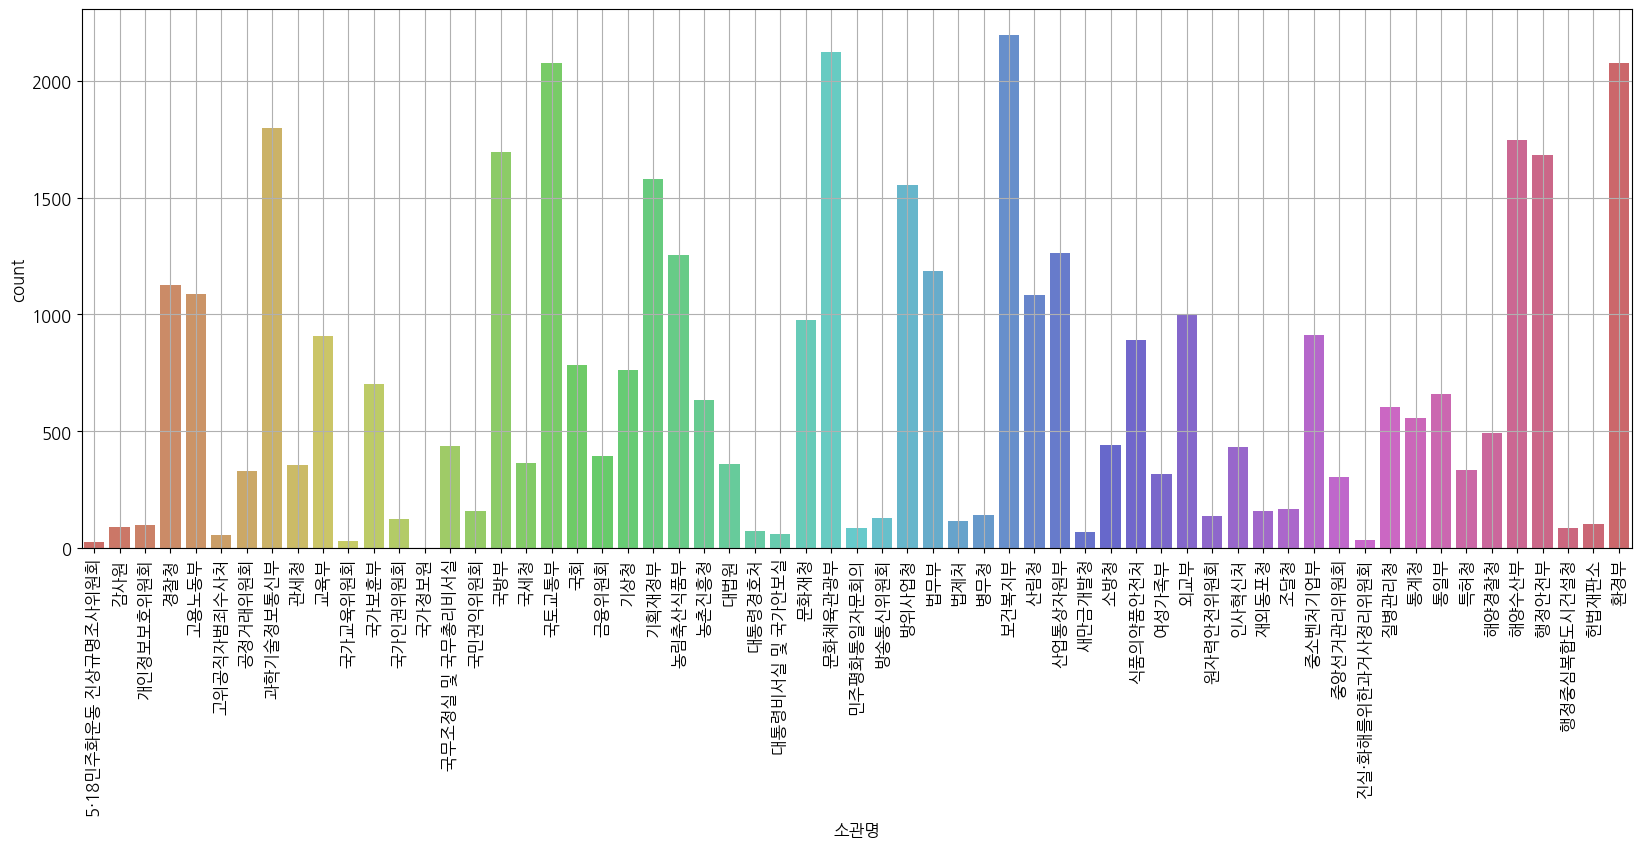

In [14]:
#소관명별 세출예산 빈도 시각화 분석
plt.rcParams['font.size']=12

plt.figure(figsize=(20,7))
plt.xticks(rotation=90)
sns.countplot(x='소관명', data=세출예산편성_DF,palette='hls')
plt.grid()
plt.show()

In [15]:
#인덱스 재구성
소관별_차이금액.reset_index(inplace=True)
소관별_차이금액[:10]

#차이금액 백만원 단위 변환
소관별_차이금액['차이금액_백만'] = round(소관별_차이금액.차이금액/1000)
소관별_차이금액[:10]

,소관명,차이금액,차이금액_백만
0,5·18민주화운동 진상규명조사위원회,0,0
1,감사원,550000,550
2,개인정보보호위원회,-920000,-920
3,경찰청,-39658000,-39658
4,고용노동부,-46642000,-46642
5,고위공직자범죄수사처,-476100,-476
6,공정거래위원회,50000,50
7,과학기술정보통신부,-213200000,-213200
8,관세청,-4752000,-4752
9,교육부,-350436000,-350436


/var/folders/pj/8ypmm1dx3971ch18spgwm3qc0000gn/T/ipykernel_52064/293078425.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='소관명',y='차이금액_백만',data=소관별_차이금액[소관별_차이금액.차이금액_백만 > 0], palette='hls')


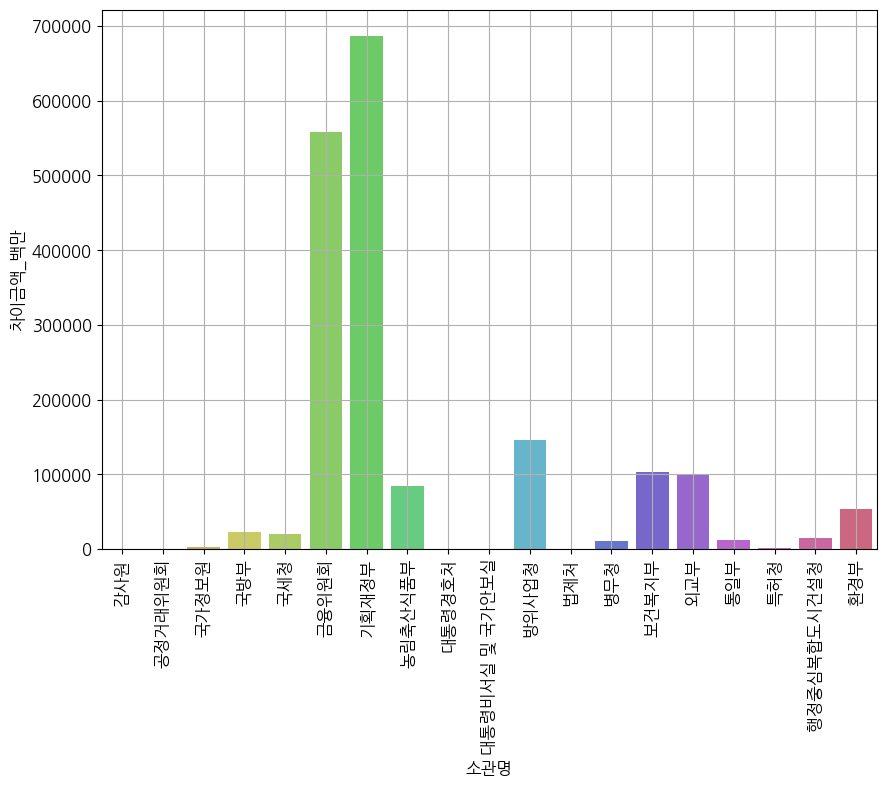

In [16]:
#정부안금액이 큰(국회에서 세입 축소된)소관명별 금액
plt.figure(figsize=(10,7))
plt.xticks(rotation=90)
sns.barplot(x='소관명',y='차이금액_백만',data=소관별_차이금액[소관별_차이금액.차이금액_백만 > 0], palette='hls')
plt.grid()
plt.show()

/var/folders/pj/8ypmm1dx3971ch18spgwm3qc0000gn/T/ipykernel_52064/532904017.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='소관명',y='차이금액_백만',data=소관별_차이금액[소관별_차이금액.차이금액_백만 < 0], palette='hls')


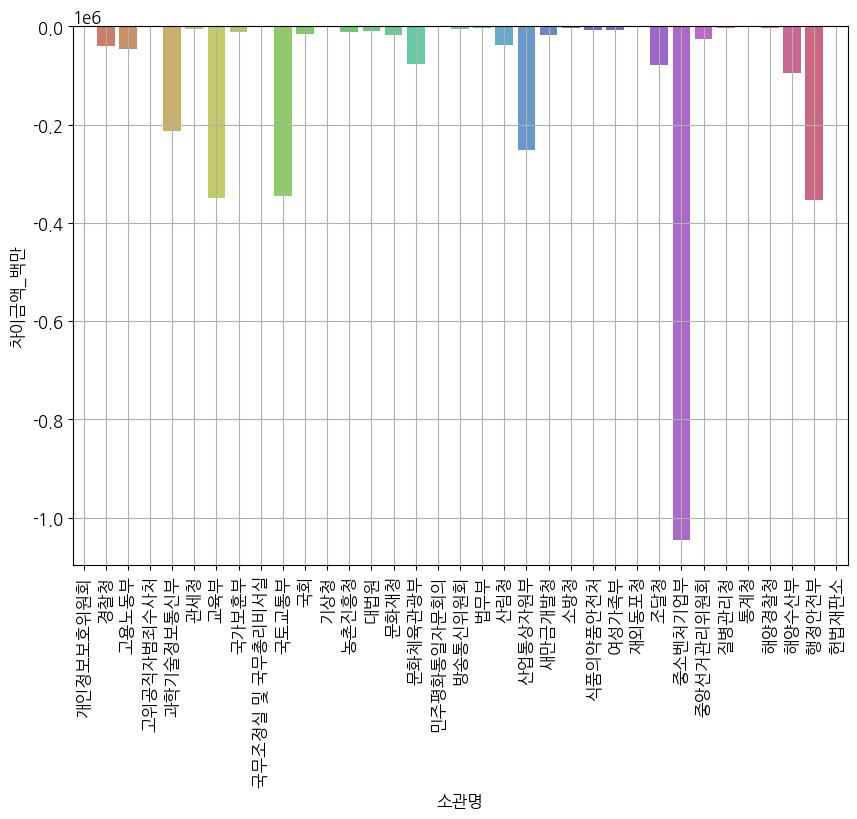

In [17]:
#국회확정금액이 큰(국회에서 세입 확대된)소관명별 금액
plt.figure(figsize=(10,7))
plt.xticks(rotation=90)
plt.rc('axes',unicode_minus=False)
sns.barplot(x='소관명',y='차이금액_백만',data=소관별_차이금액[소관별_차이금액.차이금액_백만 < 0], palette='hls')
plt.grid()
plt.show()

<Axes: xlabel='분야명', ylabel='부문명'>

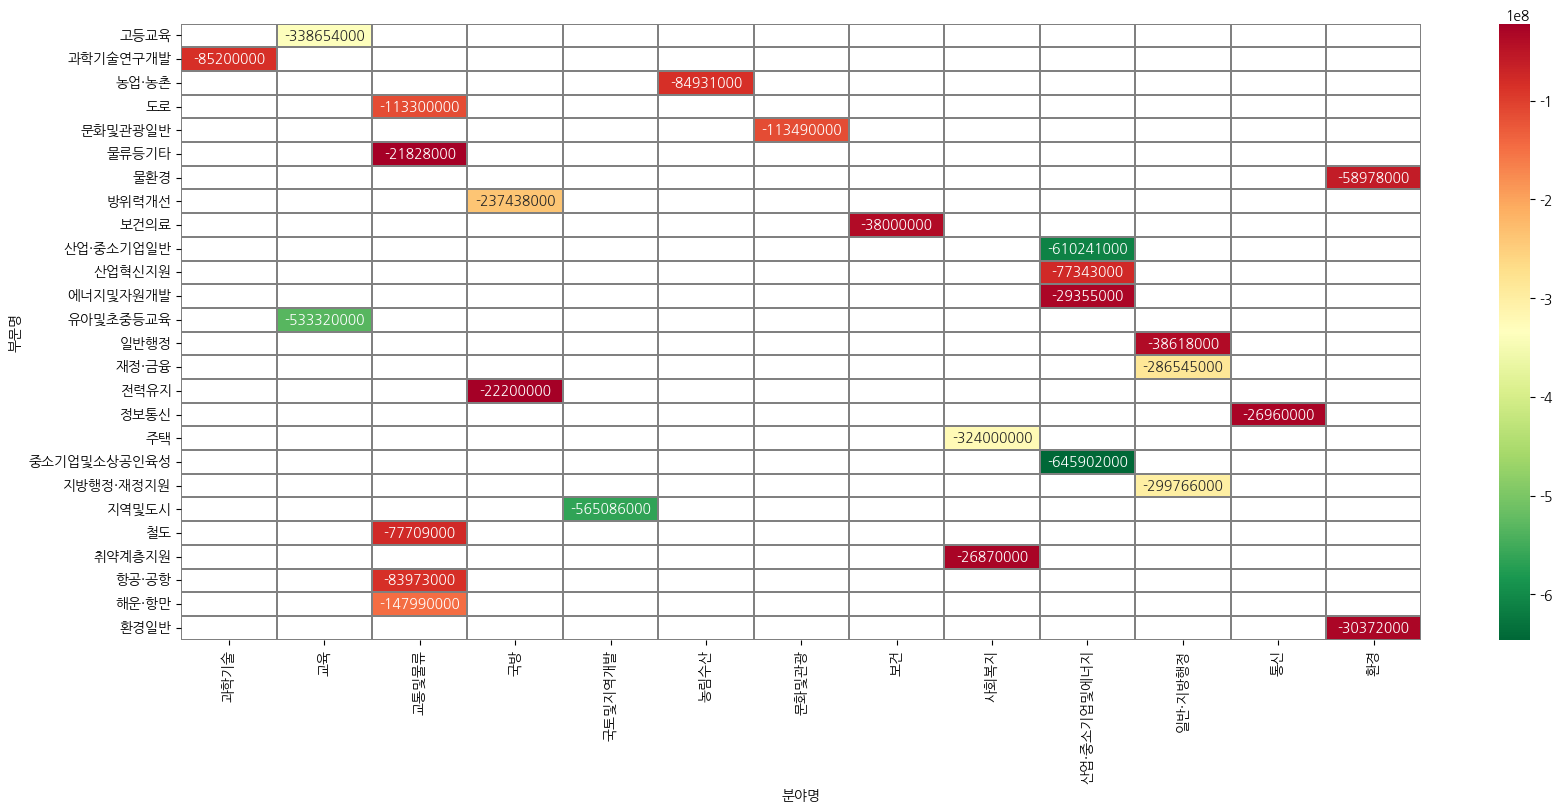

In [18]:
# 교차 차이금액(20억 이상) 분석

세출예산편성_금액20억확대 = 세출예산편성_DF[세출예산편성_DF.차이금액 < -20000000].pivot_table('차이금액', index='부문명', columns='분야명', aggfunc='sum')

# HeadMap을 이용한 교차 차이금액(20억 이상) 시각화
plt.rcParams['font.size']=10
f,ax= plt.subplots(figsize=(20,8))
plt.xticks(rotation=90)
sns.heatmap(세출예산편성_금액20억확대, annot=True, fmt='.0f', cmap='RdYlGn_r',linewidths=0.1,linecolor='grey')

In [19]:
#국회확정금액 억단위 변환
세출예산편성_DF['국회확정금액_억'] = round(세출예산편성_DF.국회확정금액 / 100000)


In [20]:
# 소관명별 부문별 세출 금액 비율 시각화 분석
소관명_부문명별_금액 = pd.DataFrame(세출예산편성_DF.groupby(['소관명','부문명']).국회확정금액_억.sum())
소관명_부문명별_금액.reset_index(drop=False,inplace=True)
소관명_부문명별_금액

,소관명,부문명,국회확정금액_억
0,5·18민주화운동 진상규명조사위원회,일반행정,65
1,감사원,일반행정,1455
2,개인정보보호위원회,일반행정,210
3,개인정보보호위원회,정부자원관리,439
4,경찰청,경찰,130420
...,...,...,...
165,환경부,물환경,51580
166,환경부,수자원,21994
167,환경부,자연환경,8359
168,환경부,자원순환및환경경제,10534


In [21]:
# 환경부 기준, 소관명별 부문별 세출 금액 비율 계산

소관명별_DF = 소관명_부문명별_금액[소관명_부문명별_금액.소관명 == '환경부']
소관명별_DF['비율'] = 소관명별_DF.국회확정금액_억 / 소관명별_DF.국회확정금액_억.sum()

with pd.option_context('display.float_format','{:.4f}'.format):
    display(소관명별_DF)

/var/folders/pj/8ypmm1dx3971ch18spgwm3qc0000gn/T/ipykernel_52064/2156496229.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  소관명별_DF['비율'] = 소관명별_DF.국회확정금액_억 / 소관명별_DF.국회확정금액_억.sum()


,소관명,부문명,국회확정금액_억,비율
163,환경부,기후대기및환경안전,40404.0000,0.1899
164,환경부,물류등기타,96.0000,0.0005
165,환경부,물환경,51580.0000,0.2425
166,환경부,수자원,21994.0000,0.1034
167,환경부,자연환경,8359.0000,0.0393
168,환경부,자원순환및환경경제,10534.0000,0.0495
169,환경부,환경일반,79758.0000,0.3749


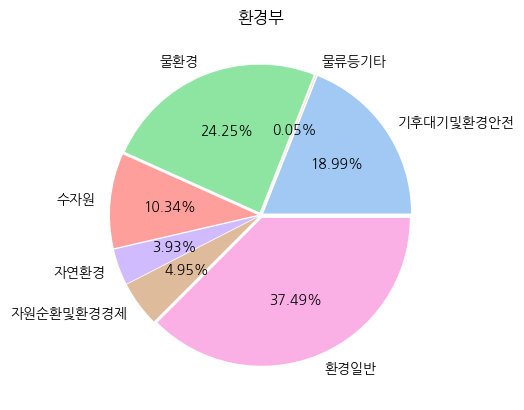

In [22]:
#Pic Chart를 이용한 소관명별 부문별 세출금애 비율 시각화 분석

explode = [0.02 for i in 소관명별_DF.부문명]
colors = sns.color_palette('pastel')
plt.pie(소관명별_DF.비율, labels=소관명별_DF.부문명, autopct='%.2f%%', explode = explode, colors=colors)
plt.title('환경부')
plt.show()